# Day 2: Clustering with K-Means

<a target="_blank" href="https://colab.research.google.com/github/LuWidme/uk259/blob/rework/demos/05_Clustering_KMeans.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Time budget:** ~75 min · **Day 2** — K-Means + penguin clustering; from-scratch is bonus.


**Duration:** 2-3 hours  
**Prerequisites:** NumPy basics, Pandas fundamentals, data visualization  

**Learning Objectives:**
- Understand what clustering is and when to use it
- Learn how the K-Means algorithm works step-by-step
- Apply sklearn's KMeans to real-world problems
- (Optional bonus) Implement K-Means from scratch to see how it works under the hood
- Determine the optimal number of clusters using the Elbow Method

**Datasets Used:** Synthetic blob data (generated), Palmer Penguins (real measurements)

---

In [1]:
# === COURSE SETUP — run this cell first! ===
# Installs the required packages (most are preinstalled on Google Colab)
# and downloads the course datasets so the notebook works out of the box.
%pip install -q numpy pandas matplotlib seaborn scikit-learn

import os, urllib.request

DATA_URL = "https://raw.githubusercontent.com/LuWidme/uk259/rework/datasets/"
for folder in ("datasets", os.path.join("..", "datasets")):
    os.makedirs(folder, exist_ok=True)
    for fname in ['titanic.csv', 'melb_data.csv', 'Company_data.csv']:
        path = os.path.join(folder, fname)
        if not os.path.exists(path):
            urllib.request.urlretrieve(DATA_URL + fname, path)

print("Setup complete — you are ready to go!")

Note: you may need to restart the kernel to use updated packages.
Setup complete — you are ready to go!


## What is Clustering?

**Simple explanation:** Clustering is the task of automatically grouping similar things together without being told what to look for.

**Real-world analogy:** Imagine you have 1000 customers and want to group them by shopping behavior. You don't know in advance what groups exist—clustering discovers them automatically by finding customers who behave similarly.

### Why is Clustering Important?

Clustering is a type of **unsupervised learning**—there are no labels or "correct answers." The algorithm finds patterns on its own.

**Common applications:**
- **Customer segmentation**: Group customers by purchasing behavior for targeted marketing
- **Image compression**: Reduce colors in an image by grouping similar colors
- **Document organization**: Group similar news articles or research papers
- **Anomaly detection**: Find unusual data points that don't fit any cluster
- **Gene sequence analysis**: Group genes with similar expression patterns

### What is K-Means?

**K-Means** is one of the most popular clustering algorithms. It groups data into **K clusters** where:
- **K** is the number of clusters (you choose this)
- **Means** refers to the average (center) of each cluster

**How it works (intuitive explanation):**
1. Place K random points as initial cluster centers
2. Assign each data point to its nearest cluster center
3. Move each cluster center to the average position of all points assigned to it
4. Repeat steps 2-3 until cluster centers stop moving (or move very little)


---

## Setup

Let's import the libraries we'll need:

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances_argmin

# Set style for better-looking plots
sns.set_style('whitegrid')
%matplotlib inline

---

## Part 1: Generate Synthetic Data

We'll start by creating a synthetic dataset with known clusters. This helps us understand if our algorithm is working correctly.

The `make_blobs` function from scikit-learn generates random data points grouped into clusters.

In [3]:
# Generate synthetic dataset with 4 underlying clusters
features, true_labels = make_blobs(
    n_samples=500,       # 500 data points
    centers=4,           # 4 true clusters
    cluster_std=1.0,     # Standard deviation of clusters (spread)
    random_state=42      # For reproducibility
)

print("Dataset shape:", features.shape)
print("First 5 data points:")
print(features[:5])
print("\nFirst 5 true labels:")
print(true_labels[:5])

Dataset shape: (500, 2)
First 5 data points:
[[-7.68905443  6.62034649]
 [-9.57651383 -6.93440446]
 [ 6.82968177  1.1648714 ]
 [-2.90130578  7.55077118]
 [-5.67841327 -7.28818497]]

First 5 true labels:
[3 2 1 0 2]


### Visualize the Data

Let's plot the data **without** showing the true labels. This is what we'd see in a real-world scenario—unlabeled data that we want to cluster.

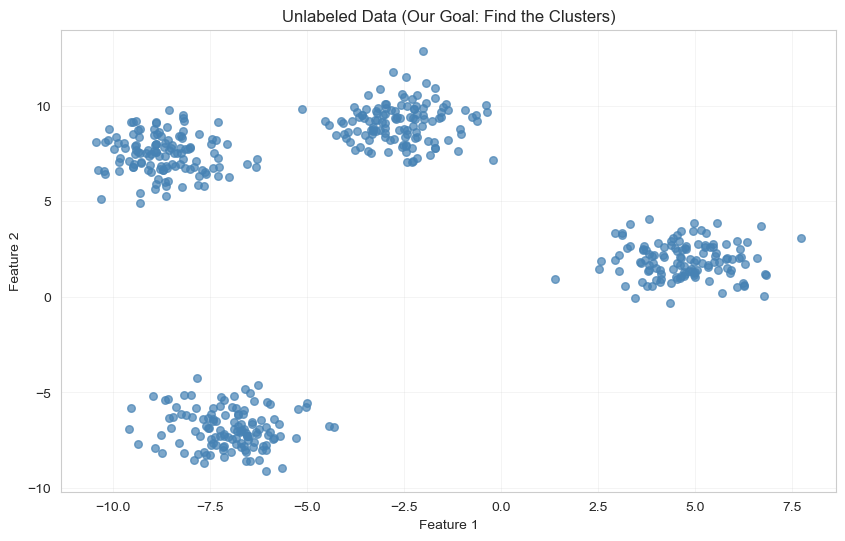

In [4]:
# Visualize the unlabeled data
plt.figure(figsize=(10, 6))
plt.scatter(features[:, 0], features[:, 1], s=30, alpha=0.7, c='steelblue')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Unlabeled Data (Our Goal: Find the Clusters)')
plt.grid(True, alpha=0.3)
plt.show()

**Can you visually identify the clusters?** Even though we haven't run any algorithm yet, humans can often spot patterns. K-Means will automate this process mathematically.

---

## Part 2: Clustering with Scikit-learn's KMeans

In practice you rarely implement K-Means yourself — scikit-learn provides a fast, robust version that clusters data in just a few lines of code. (Curious how the algorithm actually works step-by-step? See the optional **"Implement K-Means from Scratch"** bonus section near the end of this notebook.)

**Why use sklearn's KMeans?**
- **Optimized**: Faster C implementations
- **Features**: Multiple initialization strategies, parallel processing
- **Robust**: Handles edge cases (empty clusters, etc.)
- **Consistent API**: Works with other sklearn tools


In [5]:
# Create and fit KMeans model
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
sklearn_labels = kmeans.fit_predict(features)
sklearn_centers = kmeans.cluster_centers_

print("Sklearn KMeans results:")
print(f"Number of iterations: {kmeans.n_iter_}")
print(f"\nCluster centers:")
print(sklearn_centers)
print(f"\nInertia (sum of squared distances to centers): {kmeans.inertia_:.2f}")

Sklearn KMeans results:
Number of iterations: 2

Cluster centers:
[[ 4.72182456  1.9238556 ]
 [-8.68153751  7.4554521 ]
 [-7.0009649  -6.90445754]
 [-2.60221541  9.09243505]]

Inertia (sum of squared distances to centers): 948.89


C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


### Compare the Clusters with the Ground Truth

Because we generated this data ourselves, we know the *true* groups. Let's see how well K-Means recovered them:


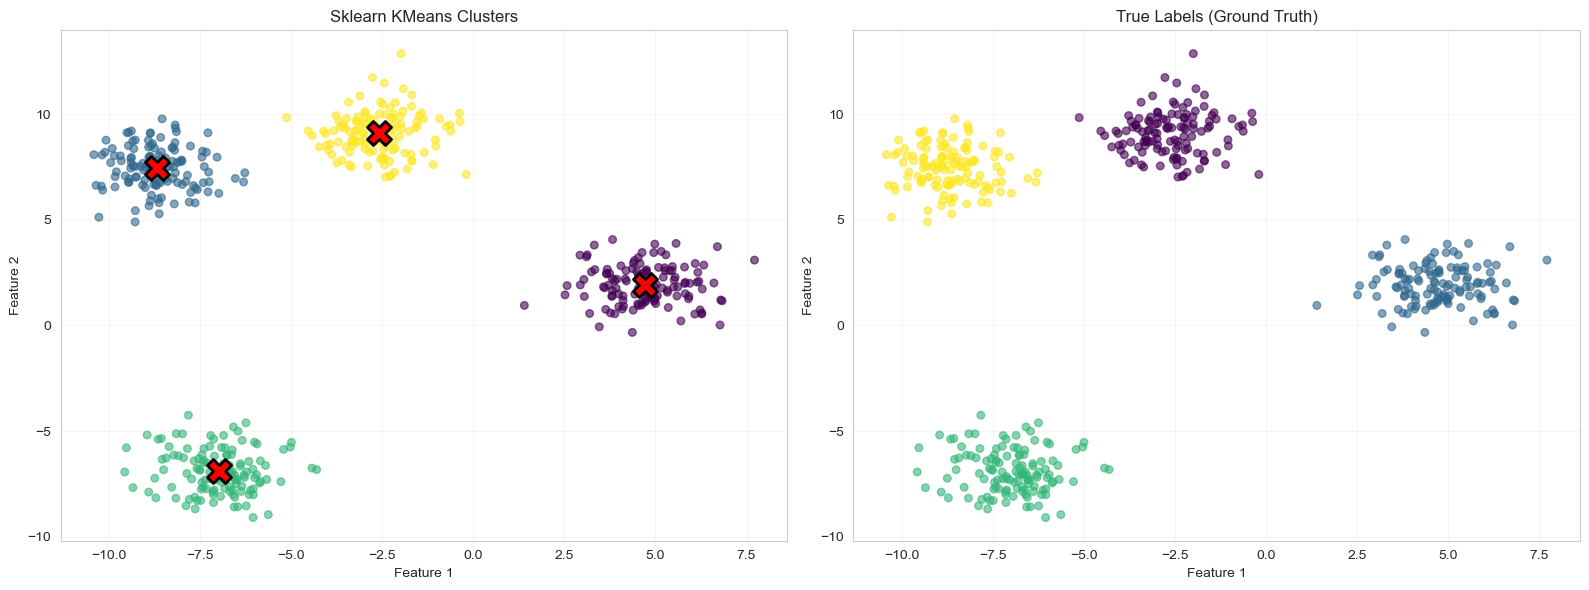

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sklearn clustering result
axes[0].scatter(features[:, 0], features[:, 1], s=30, alpha=0.6,
                c=sklearn_labels, cmap='viridis')
axes[0].scatter(sklearn_centers[:, 0], sklearn_centers[:, 1],
                s=300, c='red', marker='X', edgecolors='black', linewidths=2)
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title('Sklearn KMeans Clusters')
axes[0].grid(True, alpha=0.3)

# True labels (ground truth)
axes[1].scatter(features[:, 0], features[:, 1], s=30, alpha=0.6,
                c=true_labels, cmap='viridis')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_title('True Labels (Ground Truth)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---

## Part 3: Choosing the Optimal Number of Clusters

**Problem:** How do we know K=4 is the right choice? In real-world problems, we don't know the true number of clusters.

### The Elbow Method

The **Elbow Method** helps us choose K by:
1. Running K-Means for different values of K (e.g., K=1 to 10)
2. Calculating the **inertia** (sum of squared distances from points to their cluster center)
3. Plotting inertia vs. K
4. Looking for an "elbow" where inertia starts decreasing more slowly

**Intuition:** 
- More clusters → lower inertia (points closer to centers)
- But too many clusters → overfitting (every point is its own cluster!)
- The elbow is the "sweet spot"

### Exercise 1: Implement the Elbow Method

**Instructions:**
1. Loop through K values from 1 to 10
2. For each K, fit KMeans and record the inertia
3. Plot K vs. inertia
4. Identify the elbow point

**Hint:** Use `kmeans.inertia_` to get the inertia after fitting.

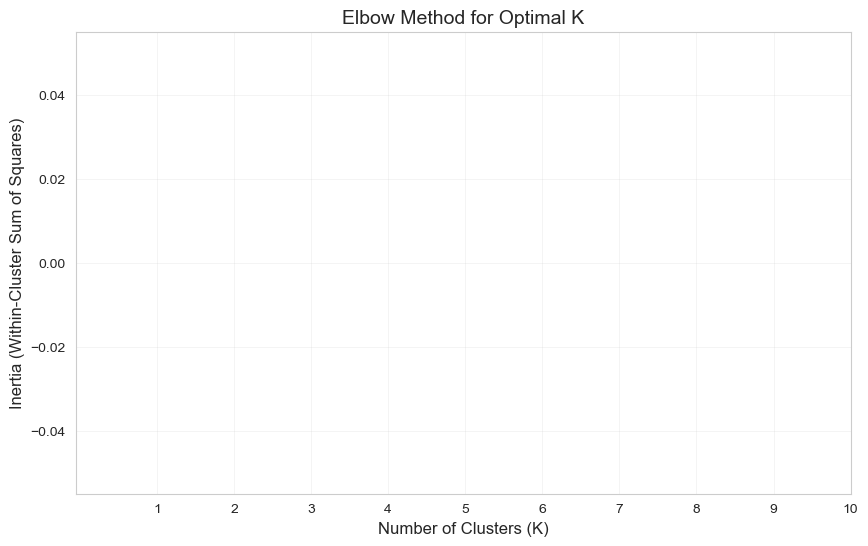

Inertia values:


TypeError: unsupported format string passed to NoneType.__format__

In [7]:
# TODO: Implement the Elbow Method
k_values = range(1, 11)
inertias = []

for k in k_values:
    # Fit KMeans with k clusters
    kmeans = None  # Create KMeans model
    # Fit to data
    # Append inertia to list
    inertias.append(None)

# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.show()

print("Inertia values:")
for k, inertia in zip(k_values, inertias):
    print(f"  K={k}: {inertia:.2f}")

**Question:** Where is the elbow in your plot? What does this tell you about the optimal number of clusters?

---

## Part 4: Main Exercise — Discovering Penguin Groups

**This is today's main exercise.** Apply everything above to a *real* dataset where — unlike our synthetic blobs — the "right" number of clusters is genuinely **not obvious**.

### Exercise 2: Clustering Penguins

We'll use the **Palmer Penguins** dataset: physical measurements of penguins observed near Palmer Station, Antarctica. Each penguin has four measurements:

- **bill_length_mm** — length of the bill (beak)
- **bill_depth_mm** — depth of the bill
- **flipper_length_mm** — flipper length
- **body_mass_g** — body weight in grams

**The twist:** In the synthetic example we *knew* there were 4 clusters. Here, nobody tells us how many natural groups the penguins fall into. Two groups? Three? More? That is exactly the situation you face with real data — and exactly what the Elbow Method is for.

> **Note:** The dataset *does* contain a hidden `species` column, but we keep it away from the algorithm — clustering is **unsupervised**. We'll peek at it only at the very end to check how well our discovered clusters match reality.

First, let's load and prepare the data:

Dataset: 342 penguins, 4 features
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count           342.0          342.0              342.0        342.0
mean             43.9           17.2              200.9       4201.8
std               5.5            2.0               14.1        802.0
min              32.1           13.1              172.0       2700.0
25%              39.2           15.6              190.0       3550.0
50%              44.4           17.3              197.0       4050.0
75%              48.5           18.7              213.0       4750.0
max              59.6           21.5              231.0       6300.0


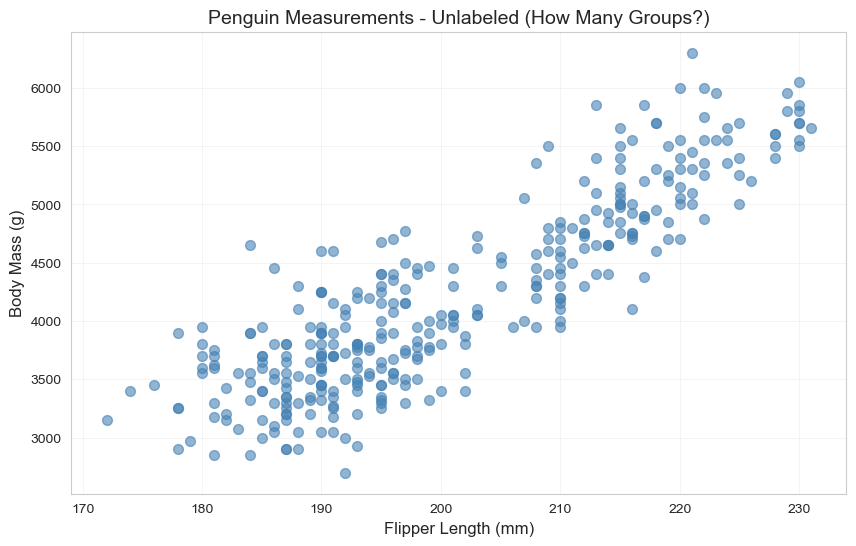

In [8]:
# Load the Palmer Penguins dataset (built into seaborn)
penguins = sns.load_dataset('penguins')

# Use the four numeric measurements and drop rows with missing values
feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
penguins = penguins.dropna(subset=feature_cols).reset_index(drop=True)

X = penguins[feature_cols].values

# Scale the features! The measurements live on very different scales
# (body_mass_g is in the thousands, bill_length_mm in the tens). K-Means uses
# distances, so without scaling body mass would completely dominate the result.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset: {penguins.shape[0]} penguins, {len(feature_cols)} features")
print(penguins[feature_cols].describe().round(1))

# Visualize two of the four measurements. The data is 4-dimensional, so this is
# only a slice — and notice there is no obviously "correct" number of groups.
plt.figure(figsize=(10, 6))
plt.scatter(penguins['flipper_length_mm'], penguins['body_mass_g'],
            s=50, alpha=0.6, c='steelblue')
plt.xlabel('Flipper Length (mm)', fontsize=12)
plt.ylabel('Body Mass (g)', fontsize=12)
plt.title('Penguin Measurements - Unlabeled (How Many Groups?)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### Task: Discover the Penguin Groups

**Instructions:**
1. Use the Elbow Method on the **scaled** data (`X_scaled`) to find a reasonable K
2. Apply K-Means with the K you chose
3. Visualize the resulting clusters
4. **Reveal:** compare your clusters to the hidden `species` column — how many groups did the data really have?

**Important:** Always cluster on `X_scaled`, *not* on the raw `X`. Otherwise body mass (in the thousands) dominates the distance calculation and bill length barely matters.

In [ ]:
# TODO: Apply the Elbow Method to the scaled penguin data (X_scaled)
k_values = range(2, 11)
inertias = []

for k in k_values:
    # Your code here: fit KMeans on X_scaled and record kmeans.inertia_
    pass

# Plot elbow curve
plt.figure(figsize=(10, 6))
# Your plotting code here
plt.show()

In [ ]:
# TODO: Apply K-Means with the K you chose (based on your elbow plot)
optimal_k = None  # Set this based on your elbow plot

kmeans_penguins = None   # Create the KMeans model
penguin_labels = None    # Fit and predict on X_scaled

# Visualize the clusters. The data has 4 dimensions, so plot a 2D slice
# (e.g. flipper_length_mm vs body_mass_g) and color the points by their cluster.
plt.figure(figsize=(12, 8))
# Your visualization code here
plt.show()

### Reveal: How Many Groups Were There *Really*?

Time to use the hidden `species` column the algorithm never saw. The cell below
cross-tabulates your clusters against the true species, so you can see whether
each cluster lines up with a real penguin species.

**Reflect:**
- How many K did your elbow plot suggest? Did the elbow even have a single clear "kink"?
- The dataset has **3 species** (Adelie, Chinstrap, Gentoo). Did K-Means recover them — or did it prefer to split the data into 2 groups (e.g. big vs. small penguins)?
- This is the key lesson: with real data the "correct" number of clusters is often **ambiguous**, and the Elbow Method gives you a *suggestion*, not a guaranteed answer.

In [ ]:
# Compare your discovered clusters with the true species (unseen by the algorithm)
comparison = pd.crosstab(penguin_labels, penguins['species'],
                         rownames=['Cluster'], colnames=['True species'])
print(comparison)

## Part 5: Limitations and Best Practices

### Limitations of K-Means

K-Means is powerful but has limitations:

1. **Must specify K in advance** - doesn't automatically find the number of clusters
2. **Assumes spherical clusters** - struggles with elongated or irregular shapes
3. **Sensitive to initialization** - different starting points can give different results
4. **Affected by outliers** - outliers can pull cluster centers away
5. **Assumes similar cluster sizes** - unbalanced clusters can be problematic
6. **Sensitive to scale** - features with larger ranges dominate distance calculations

### Best Practices

**Before clustering:**
- ✓ **Scale your features** - use StandardScaler or MinMaxScaler
- ✓ **Handle outliers** - remove or cap extreme values
- ✓ **Remove missing values** - K-Means can't handle NaN

**During clustering:**
- ✓ **Use multiple initializations** - sklearn's `n_init` parameter (default=10)
- ✓ **Try different K values** - use Elbow Method or Silhouette Score
- ✓ **Visualize results** - inspect clusters for quality

**After clustering:**
- ✓ **Validate with domain knowledge** - do clusters make sense?
- ✓ **Calculate cluster statistics** - mean, size, spread
- ✓ **Consider alternatives** - DBSCAN for non-spherical, hierarchical for dendrograms

### When to Use K-Means vs. Other Algorithms

| Algorithm | Best for | Limitations |
|-----------|----------|-------------|
| **K-Means** | Large datasets, spherical clusters, known K | Must specify K, sensitive to outliers |
| **DBSCAN** | Arbitrary shapes, noisy data | Struggles with varying density |
| **Hierarchical** | Small datasets, dendrogram needed | Slow on large datasets |
| **Gaussian Mixture** | Soft assignments, elliptical clusters | More complex, slower than K-Means |

---

## Bonus (optional): Implement K-Means from Scratch

> **Optional deep-dive.** You've already clustered data with sklearn above — this section is for the curious who want to see exactly how the algorithm works. Skip it if you're short on time and come back later.

To truly understand K-Means, we'll implement it step-by-step.

### Task 1: Initialize Cluster Centers

**Goal:** Create initial positions for the K cluster centers.

**Strategy:** We'll randomly select K data points from our dataset as initial centers. This is called the **Forgy initialization method**.

**Instructions:**
1. Use `np.random.choice()` to randomly select K indices from the dataset
2. Use these indices to pick K points as initial cluster centers
3. Return these centers as a 2D NumPy array

**Hint:** Look at the shape of `features` to understand what shape `cluster_centers` should have.

In [ ]:
def initialize_centers(data, k):
    """
    Initialize K cluster centers by randomly selecting K data points.
    
    Parameters:
    -----------
    data : ndarray of shape (n_samples, n_features)
        The input data
    k : int
        Number of clusters
    
    Returns:
    --------
    centers : ndarray of shape (k, n_features)
        Initial cluster centers
    """
    # TODO: Randomly select k data points as initial centers
    n_samples = data.shape[0]
    indices = None  # Use np.random.choice() to select k random indices
    centers = None  # Use these indices to get the corresponding data points
    
    return centers

# Test your function
initial_centers = initialize_centers(features, k=4)
print("Initial cluster centers shape:", initial_centers.shape)
print("Initial centers:")
print(initial_centers)

### Visualize Initial Centers

Let's see where our random initial centers are located:

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(features[:, 0], features[:, 1], s=30, alpha=0.5, c='steelblue', label='Data points')
plt.scatter(initial_centers[:, 0], initial_centers[:, 1], 
            s=300, c='red', marker='X', edgecolors='black', linewidths=2,
            label='Initial centers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data Points with Initial Cluster Centers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

### Task 2: Assign Points to Nearest Cluster

**Goal:** For each data point, find which cluster center is closest.

**How to measure distance?** We'll use **Euclidean distance** (straight-line distance):

$$\text{distance} = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2}$$

**Instructions:**
1. For each point, calculate the distance to all cluster centers
2. Assign the point to the cluster with the smallest distance
3. Return an array of cluster assignments (one label per point)

**Hint:** You can use `np.linalg.norm()` or write your own distance function. The function `pairwise_distances_argmin` from sklearn can also help.

In [ ]:
def assign_clusters(data, centers):
    """
    Assign each data point to the nearest cluster center.
    
    Parameters:
    -----------
    data : ndarray of shape (n_samples, n_features)
        The input data
    centers : ndarray of shape (k, n_features)
        Current cluster centers
    
    Returns:
    --------
    labels : ndarray of shape (n_samples,)
        Cluster assignment for each data point (0 to k-1)
    """
    # TODO: Assign each point to its nearest center
    # Option 1: Use sklearn's pairwise_distances_argmin
    # Option 2: Write your own distance calculation loop
    
    labels = None  # This should be an array of length n_samples
    
    return labels

# Test your function
cluster_assignments = assign_clusters(features, initial_centers)
print("Cluster assignments shape:", cluster_assignments.shape)
print("First 10 assignments:", cluster_assignments[:10])
print("Unique clusters:", np.unique(cluster_assignments))

### Visualize Initial Cluster Assignments

Let's see how points are grouped after the first assignment step:

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(features[:, 0], features[:, 1], s=30, alpha=0.6, 
            c=cluster_assignments, cmap='viridis', label='Data points')
plt.scatter(initial_centers[:, 0], initial_centers[:, 1], 
            s=300, c='red', marker='X', edgecolors='black', linewidths=2,
            label='Cluster centers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Initial Cluster Assignments')
plt.colorbar(label='Cluster ID')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

### Task 3: Update Cluster Centers

**Goal:** Move each cluster center to the average position of all points assigned to it.

**Why?** This step finds the "mean" (average) of each cluster, which is why the algorithm is called "K-**Means**".

**Math:** For cluster $j$, the new center is:

$$\text{center}_j = \frac{1}{|C_j|} \sum_{\text{point } i \in C_j} \text{point}_i$$

In plain English: Average the coordinates of all points in the cluster.

**Instructions:**
1. For each cluster (0 to k-1), find all points assigned to it
2. Calculate the mean of these points along each feature dimension
3. Set this mean as the new cluster center

**Hint:** Use boolean indexing (`data[labels == j]`) and `np.mean()` with the correct axis.

In [ ]:
def update_centers(data, labels, k):
    """
    Update cluster centers to the mean of assigned points.
    
    Parameters:
    -----------
    data : ndarray of shape (n_samples, n_features)
        The input data
    labels : ndarray of shape (n_samples,)
        Current cluster assignments
    k : int
        Number of clusters
    
    Returns:
    --------
    new_centers : ndarray of shape (k, n_features)
        Updated cluster centers
    """
    n_features = data.shape[1]
    new_centers = np.zeros((k, n_features))
    
    # TODO: For each cluster, calculate the mean of assigned points
    for j in range(k):
        # Get all points assigned to cluster j
        cluster_points = None  # Use boolean indexing: data[labels == j]
        # Calculate mean along axis 0 (average each feature)
        new_centers[j] = None  # Use np.mean()
    
    return new_centers

# Test your function
updated_centers = update_centers(features, cluster_assignments, k=4)
print("Updated cluster centers:")
print(updated_centers)
print("\nCenter movement (distance from initial):")
for i in range(4):
    distance = np.linalg.norm(updated_centers[i] - initial_centers[i])
    print(f"  Cluster {i}: moved {distance:.2f} units")

### Visualize Updated Centers

Let's see how the centers moved after one iteration:

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(features[:, 0], features[:, 1], s=30, alpha=0.5, 
            c=cluster_assignments, cmap='viridis')
plt.scatter(initial_centers[:, 0], initial_centers[:, 1], 
            s=300, c='red', marker='X', edgecolors='black', linewidths=2,
            label='Initial centers', alpha=0.5)
plt.scatter(updated_centers[:, 0], updated_centers[:, 1], 
            s=300, c='orange', marker='X', edgecolors='black', linewidths=2,
            label='Updated centers')

# Draw arrows showing center movement
for i in range(4):
    plt.arrow(initial_centers[i, 0], initial_centers[i, 1],
              updated_centers[i, 0] - initial_centers[i, 0],
              updated_centers[i, 1] - initial_centers[i, 1],
              head_width=0.3, head_length=0.2, fc='black', ec='black', alpha=0.6)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Cluster Centers After One Update (arrows show movement)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

### Task 4: Put It All Together - Complete K-Means Algorithm

**Goal:** Combine the three steps (initialize, assign, update) into a complete K-Means implementation.

**Algorithm:**
1. Initialize cluster centers
2. Repeat until convergence:
   - Assign points to nearest center
   - Update centers to mean of assigned points
3. Return final assignments and centers

**When to stop?** We'll use two stopping criteria:
- **Max iterations**: Stop after a fixed number of iterations (e.g., 100)
- **Convergence**: Stop if centers move less than a threshold (e.g., 0.001)

**Instructions:**
1. Use your functions from Tasks 1-3
2. Add a loop that repeats until convergence or max_iter reached
3. Track the center positions to detect convergence

In [ ]:
def k_means(data, k, max_iter=100, tolerance=1e-4):
    """
    Complete K-Means clustering algorithm.
    
    Parameters:
    -----------
    data : ndarray of shape (n_samples, n_features)
        The input data to cluster
    k : int
        Number of clusters
    max_iter : int, default=100
        Maximum number of iterations
    tolerance : float, default=1e-4
        Convergence threshold (stop if centers move less than this)
    
    Returns:
    --------
    labels : ndarray of shape (n_samples,)
        Final cluster assignments
    centers : ndarray of shape (k, n_features)
        Final cluster centers
    n_iter : int
        Number of iterations performed
    """
    # TODO: Initialize centers
    centers = None
    
    for iteration in range(max_iter):
        # TODO: Assign points to clusters
        labels = None
        
        # TODO: Update centers
        new_centers = None
        
        # Check for convergence
        center_shift = np.linalg.norm(new_centers - centers)
        
        if center_shift < tolerance:
            print(f"Converged after {iteration + 1} iterations")
            centers = new_centers
            break
        
        centers = new_centers
    else:
        print(f"Reached max iterations ({max_iter})")
    
    return labels, centers, iteration + 1

# Run your K-Means implementation
my_labels, my_centers, n_iterations = k_means(features, k=4)

print(f"\nClustering completed in {n_iterations} iterations")
print(f"\nFinal cluster centers:")
print(my_centers)
print(f"\nCluster sizes:")
unique, counts = np.unique(my_labels, return_counts=True)
for cluster_id, count in zip(unique, counts):
    print(f"  Cluster {cluster_id}: {count} points")

### Visualize Final Results

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Your K-Means results
axes[0].scatter(features[:, 0], features[:, 1], s=30, alpha=0.6, 
                c=my_labels, cmap='viridis')
axes[0].scatter(my_centers[:, 0], my_centers[:, 1], 
                s=300, c='red', marker='X', edgecolors='black', linewidths=2,
                label='Cluster centers')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_title('Your K-Means Implementation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: True labels (for comparison)
axes[1].scatter(features[:, 0], features[:, 1], s=30, alpha=0.6, 
                c=true_labels, cmap='viridis')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_title('True Labels (Ground Truth)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**How did your algorithm do?** Compare the left plot (your results) with the right plot (true labels). They might not match exactly because:
- Cluster IDs are arbitrary (cluster 0 in your result might be cluster 2 in the true labels)
- Random initialization can lead to different solutions

---

## Bonus Challenges

### Challenge 1: K-Means++ Initialization
Implement **K-Means++**, a smarter initialization strategy that spreads initial centers far apart. This often leads to better clustering.

### Challenge 2: Silhouette Score
Calculate the **Silhouette Score** for different K values. This metric measures how well-separated clusters are (ranges from -1 to 1, higher is better).

**Hint:** Use `sklearn.metrics.silhouette_score`

### Challenge 3: Visualize Convergence
Modify your K-Means implementation to save cluster centers at each iteration. Then create an animated GIF showing how clusters evolve.

**Hint:** Use `matplotlib.animation` or save individual frames and combine with `imageio`

### Challenge 4: Real Dataset
Apply K-Means to a real dataset from scikit-learn (e.g., Iris, Wine, Digits). Compare clustering results with true labels.

---

## Summary

Congratulations! You've learned:

✓ What clustering is and when to use it  
✓ How K-Means works algorithmically  
✓ How to implement K-Means from scratch  
✓ How to use sklearn's optimized KMeans  
✓ How to choose optimal K with the Elbow Method  
✓ How to apply clustering to real-world problems  
✓ Limitations and best practices  

### Next Steps

- **Practice**: Apply K-Means to your own datasets
- **Explore**: Try other clustering algorithms (DBSCAN, hierarchical)
- **Learn more**: Read about Gaussian Mixture Models and spectral clustering
- **Real-world**: Work on Day 5 project using clustering for unsupervised learning

### Key Takeaways

1. **Clustering finds patterns without labels** - powerful for exploratory data analysis
2. **K-Means is simple but effective** - great starting point for many problems
3. **Always validate results** - domain knowledge + metrics together
4. **Preprocessing matters** - scale features and handle outliers
5. **No single "right" answer** - clustering is subjective, multiple solutions exist

---

### Additional Resources

- [Scikit-learn Clustering Documentation](https://scikit-learn.org/stable/modules/clustering.html)
- [Visualizing K-Means Clustering](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)
- [StatQuest: K-Means Explained](https://www.youtube.com/watch?v=4b5d3muPQmA)
- [Choosing the Right Clustering Algorithm](https://scikit-learn.org/stable/modules/clustering.html#overview-of-clustering-methods)

---